In [1]:
import pandas as pd

In [2]:
import numpy as np

In [3]:
import matplotlib.pyplot as plt

In [4]:
nav = pd.read_csv("../data/processed/nav_history_cleaned.csv")

fund_scorecard = pd.read_csv(
    "../data/processed/fund_scorecard.csv"
)

investor = pd.read_csv(
    "../data/raw/08_investor_transactions.csv"
)

holdings = pd.read_csv(
    "../data/raw/09_portfolio_holdings.csv"
)

In [5]:
nav["date"] = pd.to_datetime(nav["date"])

investor["transaction_date"] = pd.to_datetime(
    investor["transaction_date"]
)

In [6]:
var_cvar = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 20:

        var95 = returns.quantile(0.05)

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_cvar.append(
            [code, var95, cvar95]
        )

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_df.head()

KeyError: 'daily_return'

In [7]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav']


In [8]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = nav.groupby(
    "amfi_code"
)["nav"].pct_change()

In [9]:
print(nav.columns.tolist())

['amfi_code', 'date', 'nav', 'daily_return']


In [10]:
var_cvar = []

for code, df in nav.groupby("amfi_code"):

    returns = df["daily_return"].dropna()

    if len(returns) > 20:

        var95 = returns.quantile(0.05)

        cvar95 = returns[
            returns <= var95
        ].mean()

        var_cvar.append(
            [code, var95, cvar95]
        )

var_cvar_df = pd.DataFrame(
    var_cvar,
    columns=[
        "amfi_code",
        "var_95",
        "cvar_95"
    ]
)

var_cvar_df.head()

,amfi_code,var_95,cvar_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [11]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [12]:
var_cvar_df.to_csv(
    "../data/processed/var_cvar_report.csv",
    index=False
)

In [13]:
var_cvar_df.shape

(40, 3)

In [14]:
top5 = (
    fund_scorecard
    .sort_values(
        "fund_score",
        ascending=False
    )
    .head(5)
)

top5

,amfi_code,cagr,alpha,beta,sharpe,sortino,max_drawdown,cagr_rank,sortino_rank,sharpe_rank,alpha_rank,mdd_rank,fund_score
39,100025,0.044551,0.043330,-0.003422,-0.567095,-0.941821,-0.043083,36.0,39.0,39.0,38.0,37.0,37.75
37,101208,0.065044,0.060852,0.000126,-0.815567,-1.681038,-0.001622,32.0,40.0,40.0,33.0,38.0,36.35
38,118636,0.053132,0.051061,-0.001969,-0.356630,-0.613525,-0.083164,35.0,38.0,38.0,35.0,35.0,36.35
36,119120,0.058853,0.056061,-0.000351,-0.226575,-0.376767,-0.043287,34.0,37.0,37.0,34.0,36.0,35.55
35,102886,0.011709,0.031949,-0.030680,-0.205832,-0.347222,-0.280011,40.0,35.0,36.0,40.0,6.0,34.55


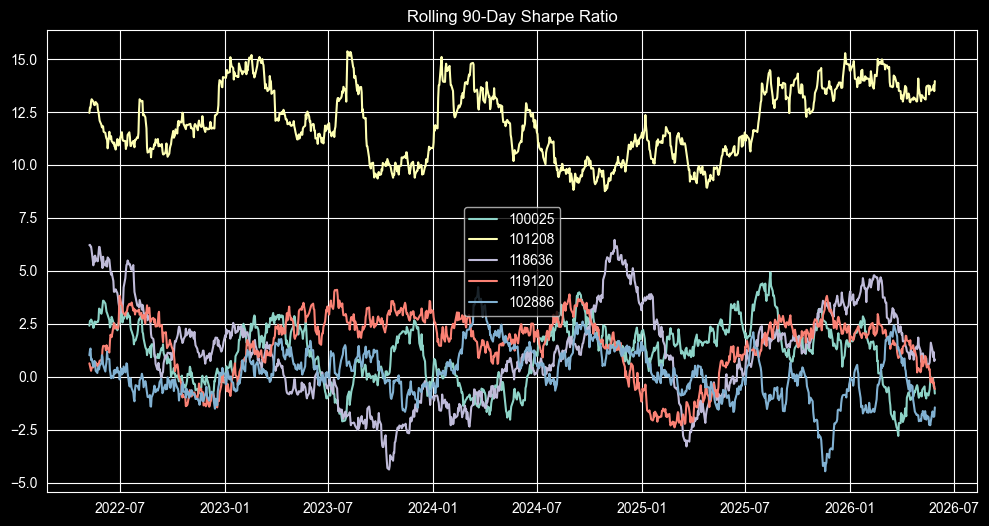

In [15]:
plt.figure(figsize=(12,6))

for code in top5["amfi_code"]:

    df = nav[
        nav["amfi_code"] == code
    ].copy()

    rolling_sharpe = (
        df["daily_return"]
        .rolling(90)
        .mean()
        /
        df["daily_return"]
        .rolling(90)
        .std()
    ) * np.sqrt(252)

    plt.plot(
        df["date"],
        rolling_sharpe,
        label=str(code)
    )

plt.legend()
plt.title(
    "Rolling 90-Day Sharpe Ratio"
)

plt.show()

In [16]:
plt.savefig(
    "../reports/rolling_sharpe_chart.png"
)

<Figure size 640x480 with 0 Axes>

In [17]:
first_txn = investor.groupby(
    "investor_id"
)["transaction_date"].min()

first_txn = first_txn.reset_index()

first_txn["cohort_year"] = (
    first_txn["transaction_date"]
    .dt.year
)

In [18]:
investor = investor.merge(
    first_txn[
        ["investor_id","cohort_year"]
    ],
    on="investor_id"
)

In [19]:
cohort_summary = investor.groupby(
    "cohort_year"
).agg({

    "amount_inr":"mean",

    "investor_id":"nunique"

}).reset_index()

cohort_summary

,cohort_year,amount_inr,investor_id
0,2024,107422.541832,4803
1,2025,109158.577061,197


In [20]:
investor = investor.sort_values(
    ["investor_id","transaction_date"]
)

In [21]:
investor["gap_days"] = investor.groupby(
    "investor_id"
)["transaction_date"].diff().dt.days

In [22]:
sip_gap = investor.groupby(
    "investor_id"
)["gap_days"].max()

sip_gap = sip_gap.reset_index()

sip_gap["risk_flag"] = np.where(
    sip_gap["gap_days"] > 35,
    "At Risk",
    "Healthy"
)

sip_gap.head()

,investor_id,gap_days,risk_flag
0,INV000001,71.0,At Risk
1,INV000002,114.0,At Risk
2,INV000003,238.0,At Risk
3,INV000004,265.0,At Risk
4,INV000005,167.0,At Risk


In [23]:
hhi = holdings.groupby(
    "amfi_code"
).apply(
    lambda x:
    (
        x["weight_pct"] / 100
    ).pow(2).sum()
).reset_index()

hhi.columns = [
    "amfi_code",
    "hhi"
]

hhi.head()

,amfi_code,hhi
0,100016,0.139534
1,100033,0.147592
2,101206,0.129332
3,101207,0.200700
4,102885,0.174709


In [24]:
print(nav.columns.tolist())
print(nav.head())

['amfi_code', 'date', 'nav', 'daily_return']
   amfi_code       date       nav  daily_return
0     100016 2022-01-03  520.4608           NaN
1     100016 2022-01-04  515.0971     -0.010306
2     100016 2022-01-05  521.7239      0.012865
3     100016 2022-01-06  515.7880     -0.011377
4     100016 2022-01-07  515.1639     -0.001210
